In [ ]:
import tonic
import snntorch as snn
import torch.nn as nn
import torch

import numpy as np
import pandas as pd
import random

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

SEED=100
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
dataset = tonic.datasets.NCALTECH101(save_to= './dataset')

3989376000it [05:56, 11189946.66it/s]                                


Extracting ./dataset\NCALTECH101\N-Caltech101-archive.zip to ./dataset\NCALTECH101


In [ ]:
events, target = dataset[0]
print(events.shape)
print(target)

(97785,)
BACKGROUND_Google


In [ ]:
print(dataset.__dict__.keys())

dict_keys(['location_on_system', 'transform', 'target_transform', 'transforms', 'data', 'targets', 'folder_name'])


In [ ]:
classes = sorted(set(dataset.targets))
class_to_idx = {cls: i for i, cls in enumerate(classes)}
dataset.targets = [class_to_idx[target] for target in dataset.targets]

In [ ]:
events, target = dataset[5000]
print(events.shape)
print(target)

(230188,)
40


In [ ]:
from torch.utils.data import WeightedRandomSampler, random_split

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train, val, test = random_split(dataset, [train_size, val_size, test_size])

In [ ]:
train.__dict__.keys()

dict_keys(['dataset', 'indices'])

In [ ]:
targets_counts = pd.Series(dataset.targets)

In [ ]:
train_target_counts = targets_counts.iloc[train.indices].value_counts()
print(train_target_counts.sum())
print(train_target_counts.head(5).sum())

6967
2192


In [ ]:
percentages = train_target_counts * 100 / sum(train_target_counts)
weights = 100 / np.sqrt(percentages)
weights = list(weights)

In [ ]:
sampler = WeightedRandomSampler(
    weights = weights,
    num_samples = 6967
)

In [ ]:
from tonic import DiskCachedDataset, MemoryCachedDataset
from torch.utils.data import DataLoader

batch_size = 64
    


train_transform = tonic.transforms.Compose([
        tonic.transforms.Denoise(filter_time=10000),
        tonic.transforms.Downsample(spatial_factor=0.5), 
        tonic.transforms.RandomCrop(sensor_size=(120, 90), target_size=(80, 80)),
        tonic.transforms.RandomFlipLR(sensor_size=(80, 80), p=0.5),
        tonic.transforms.ToFrame(sensor_size=(80, 80, 2), n_time_bins=30) 
    ])


val_transform = tonic.transforms.Compose([
        tonic.transforms.Denoise(filter_time=10000),
        tonic.transforms.Downsample(spatial_factor=0.5), 
        tonic.transforms.CenterCrop(sensor_size=(120, 90), size=(80, 80)),
        tonic.transforms.ToFrame(sensor_size=(80, 80, 2), n_time_bins=30) 
    ])

cached_train = MemoryCachedDataset(train, transform=train_transform)
cached_val = MemoryCachedDataset(val, transform=val_transform)
cached_test = MemoryCachedDataset(test, transform=val_transform)

train_loader = DataLoader(cached_train, batch_size = batch_size, sampler=sampler, 
                            collate_fn = tonic.collation.PadTensors(batch_first=False), 
                           num_workers=0, pin_memory=True)
            
val_loader = DataLoader(cached_val, batch_size = batch_size, 
                            collate_fn = tonic.collation.PadTensors(batch_first=False), 
                            num_workers=0, pin_memory=True)
    
test_loader = DataLoader(cached_test, batch_size = batch_size,
                            collate_fn = tonic.collation.PadTensors(batch_first=False), 
                            num_workers=0, pin_memory=True)
    

In [ ]:
train_size, val_size, test_size

(6967, 870, 872)

In [ ]:
len(train_loader) * batch_size, len(val_loader) * batch_size, len(test_loader) * batch_size

(6976, 896, 896)

In [ ]:
events, target = cached_train[2000]
print(events.shape)
print(target)

(30, 2, 80, 80)
60


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..17.0].


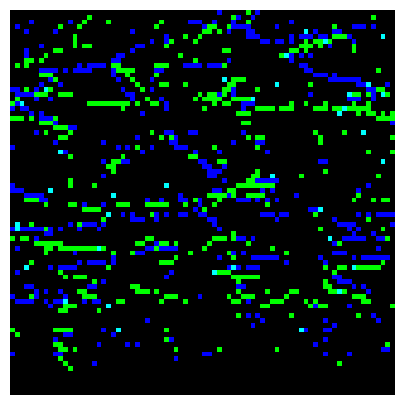

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..17.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..17.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..8.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..10.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..13.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..16.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..15.0].
Clipping input data to the valid range for imshow with RGB data ([0..1

In [ ]:
from IPython.display import HTML
animation = tonic.utils.plot_animation(events)
HTML(animation.to_jshtml())

In [ ]:
class ConvNet(nn.Module):
  def __init__(self, in_ch, out_ch, beta, threshold, population):
    super().__init__()

    self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size = 3, padding = "same")
    self.mp1 = nn.MaxPool2d(2)
    self.lif1 = snn.Leaky(beta=beta, threshold=threshold, learn_beta=True, learn_threshold=True)

    self.conv2 = nn.Conv2d(out_ch, out_ch * 2, kernel_size = 3, padding = "same")
    self.mp2 = nn.MaxPool2d(2)
    self.lif2 = snn.Leaky(beta=beta, threshold=threshold, learn_beta=True, learn_threshold=True)

    self.conv3 = nn.Conv2d(out_ch * 2, out_ch * 4, kernel_size = 3, padding = "same")
    self.mp3 = nn.MaxPool2d(2)
    self.lif3 = snn.Leaky(beta=beta, threshold=threshold, learn_beta=True, learn_threshold=True)

    self.fc1 = nn.Linear(out_ch * 4 * 10 * 10, 256)
    self.lif4 = snn.Leaky(beta=beta, threshold=threshold, learn_beta=True, learn_threshold=True)

    self.fc2 = nn.Linear(256, 101 * population)
    self.lif5 = snn.Leaky(beta=beta, threshold=threshold, learn_beta=True, learn_threshold=True)

  def forward(self, x):

    mem1 = self.lif1.init_leaky()
    mem2 = self.lif2.init_leaky()
    mem3 = self.lif3.init_leaky()
    mem4 = self.lif4.init_leaky()
    mem5 = self.lif5.init_leaky()

    spk5_rec = []

    for step in range(x.shape[0]):

      cur1 = self.conv1(x[step])
      spk1, mem1 = self.lif1(self.mp1(cur1), mem1)
      cur2 = self.conv2(spk1)
      spk2, mem2 = self.lif2(self.mp2(cur2), mem2)
      cur3 = self.conv3(spk2)
      spk3, mem3 = self.lif3(self.mp3(cur3), mem3)

      cur4 = self.fc1(spk3.flatten(1))
      spk4, mem4 = self.lif4(cur4, mem4)
      cur5 = self.fc2(spk4)
      spk5, mem5 = self.lif5(cur5, mem5)

      spk5_rec.append(spk5)

    return torch.stack(spk5_rec, dim = 0), None

In [ ]:
convnet = ConvNet(2, 4, beta = 0.9, threshold = 1.0, population = 10).to(device)

In [ ]:
from snntorch import functional as SF
import optuna
import joblib

In [ ]:
def measure_accuracy(model, dataloader):
  with torch.no_grad():
    model.eval()
    length = 0
    accuracy_rates = 0

    for step, (events, targets) in enumerate(dataloader):
        if step >= 20: 
            break

        events = events.to(device, dtype = torch.float, non_blocking=True)
        targets = targets.to(device, non_blocking=True).long()

        spk_rec, _ = model(events)
        print(f"Liczba impulsów: {spk_rec.sum().item()}")

        print('Obliczenie accuracy')
        accuracy_rates += SF.accuracy_rate(spk_rec, targets, population_code=True, num_classes= 101)
        length += 1
      
    accuracy = (accuracy_rates * 100 / length) 
    print(f'Accuracy obliczone: {accuracy}%')

    return accuracy

In [ ]:
import gc

In [ ]:
def objective(trial):

    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    beta = trial.suggest_float('beta', 0.85, 0.95)
    threshold = trial.suggest_float('threshold', 0.5, 1.5, log=True)
    population = trial.suggest_int('population', 5, 10)

    model = ConvNet(in_ch=2, out_ch=8, beta=beta, threshold = threshold, population=population).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    loss = SF.ce_count_loss(population_code=True, num_classes=101)

    epochs_per_trial = 3

    for epoch in range(epochs_per_trial):
        model.train()
        for step, (events, targets) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            if step >= 20:
                break

            events = events.to(device, dtype = torch.float, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()

            optimizer.zero_grad(set_to_none=True)
            spk_rec, _ = model(events)
            
            total_spikes = spk_rec.sum().item()
            print(f"Liczba impulsów: {spk_rec.sum().item()}")

            if step >= 3:
                if total_spikes == 0.0:
                    del model, optimizer
                    gc.collect()
                    torch.cuda.empty_cache()
                    raise optuna.exceptions.TrialPruned()
            
            loss_val = loss(spk_rec, targets)
            loss_val.backward()
            optimizer.step()


        print(f'Walidacja')
        val_acc = measure_accuracy(model, val_loader)
        trial.report(val_acc, step=epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    
    print('Czyszczenie pamięci')
    del model, optimizer
    
    gc.collect()
    torch.cuda.empty_cache()

    return val_acc

In [ ]:
optimizer = torch.optim.Adam(convnet.parameters(), lr=1e-3, betas=(0.9, 0.999))
criterion = SF.ce_count_loss(population_code=True, num_classes=101)

In [ ]:
import torch.profiler as profiler
def train_step(model, dataloader, optimizer, criterion, prof):
    model.train()

    if prof is not None:
        prof.step()

    for i, (inputs, labels) in enumerate(dataloader):
        optimizer.zero_grad()
        inputs = inputs.to(device, dtype = torch.float, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        if prof is not None:
            prof.step()
        if i >= 5:
            break

with profiler.profile(
    activities=[profiler.ProfilerActivity.CPU, 
    profiler.ProfilerActivity.CUDA],
    on_trace_ready=profiler.tensorboard_trace_handler("./log"),
    profile_memory=True,      
    with_stack=True 
) as prof:
    train_step(convnet, train_loader, optimizer, criterion, prof)

print(prof.key_averages().table(sort_by="cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::empty         0.01%       9.776ms         0.01%       9.776ms       1.829us     281.40 MB     281.40 MB       4.38 GB       4.38 GB          5345  
                                          aten::random_         0.00%      25.400us         0.00%      25.400us      25.400us           0 B           0 B           0 B           0 B             1  
         

In [ ]:
from tqdm import tqdm

In [ ]:
n_trials = 30

sampler = optuna.samplers.TPESampler()
pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=4)
study = optuna.create_study(study_name="optuna", sampler=sampler, direction='maximize', pruner=pruner, 
                            storage="sqlite:///optuna_snn.db", load_if_exists=True)

[I 2026-09-11 15:25:38,728] A new study created in RDB with name: optuna


In [ ]:
study.optimize(objective, n_trials=n_trials)

df = study.trials_dataframe()

print(f"Best accuracy: {study.best_trial.value:.4f}")
print(f"Best config: {study.best_params}")
joblib.dump(study, 'optuna.pkl')

Epoch 1:   1%|          | 1/109 [00:11<20:08, 11.19s/it]

Liczba impulsów: 74570.0


Epoch 1:   2%|▏         | 2/109 [00:22<20:26, 11.46s/it]

Liczba impulsów: 102163.0


Epoch 1:   3%|▎         | 3/109 [00:33<19:35, 11.09s/it]

...

Liczba impulsów: 121318.0


Epoch 1:   9%|▉         | 10/109 [02:25<24:33, 14.88s/it]

Liczba impulsów: 123020.0


Epoch 1:  10%|█         | 11/109 [03:06<37:14, 22.81s/it]

Liczba impulsów: 121772.0
